## Installing Dependencies

In [1]:
!pip install -q torch numpy transformers datasets evaluate


# 1. Standard ASR Evaluation Tools
!pip install evaluate jiwer librosa soundfile -q

# 2. Flashlight Text (The engine behind the CTC Beam Search)
# Note: On Kaggle/Colab, this usually requires a specific build or pre-compiled wheel
!pip install flashlight-text -q
!pip install num2words -q

import os
os.environ["MKL_NUM_THREADS"] = "4"
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["TORCHAUDIO_USE_BACKEND"] = "soundfile"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 5.3 MB/s eta 0:00:00


## Relevant Imports

In [2]:
from datasets import load_dataset, Audio
from transformers import AutoProcessor
import torch
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional, Union
import evaluate
import numpy as np
from transformers import AutoModelForCTC, TrainingArguments, Trainer
from transformers import pipeline
from torch.utils.data import Dataset

In [9]:
from transformers import Wav2Vec2Processor
import torch

def setup_processor_and_sanity_check(df_train, df_val, model_id="facebook/wav2vec2-base-960h"):
    print(f"🔄 Initializing Processor: {model_id}")
    processor = Wav2Vec2Processor.from_pretrained(model_id)
    tokenizer = processor.tokenizer
    
    vocab = tokenizer.get_vocab()
    print(f"✅ Tokenizer vocab size: {len(vocab)}")
    
    def check_chars(df, name):
        # Flatten all text into one set of characters
        all_text = "".join(df['text'].tolist())
        text_chars = set(all_text)
        
        # 960h vocab is uppercase; space maps to '|'
        # We check if the uppercase version of our char is in vocab
        missing = [c for c in text_chars if c.upper() not in vocab and c != " "]
        
        if missing:
            print(f"⚠️ {name} has chars not in vocab: {missing}")
        else:
            print(f"💎 {name} text is 100% compatible with vocab.")
        return missing

    check_chars(df_train, "Train")
    check_chars(df_val, "Val")

    # --- 1. Trash Drop ---
    def drop_trash(df):
        initial_len = len(df)
        # Ensure no empty strings survived the regex cleaning
        df = df[df['text'].str.strip().str.len() > 0].copy()
        return df

    df_train = drop_trash(df_train)
    df_val = drop_trash(df_val)
    print(f"✂️ Final cleanup: {len(df_train)} train, {len(df_val)} val samples remaining.")

    # --- 2. Audio & Text Encoding Sanity Check ---
    print("\n🧪 Running Encoding Sanity Checks...")
    
    # Dummy Audio Check (Force return_tensors="pt" to get .shape)
    dummy_input = torch.randn(16000) # 1 second of noise (1D array)
    processed_audio = processor(dummy_input, sampling_rate=16000, return_tensors="pt")
    input_values = processed_audio.input_values
    
    print(f"📻 Audio Check: Raw -> {input_values.shape} (Standardized Tensor)")

    # Tokenizer Round-trip Check
    sample_text = "kubernetes on port eight zero eight zero"
    # We pass it as uppercase because the 960h checkpoint was trained on uppercase LibriSpeech
    encoded = tokenizer(sample_text.upper()).input_ids
    decoded = tokenizer.decode(encoded)
    
    # Decoded output usually has '|' instead of spaces; we normalize for the printout
    print(f"📝 Text Check: '{sample_text}' -> {encoded[:5]}... -> '{decoded.replace('|', ' ').lower()}'")

    return processor, df_train, df_val

# --- Execution ---
processor, df_train, df_val = setup_processor_and_sanity_check(df_train, df_val)

🔄 Initializing Processor: facebook/wav2vec2-base-960h


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

✅ Tokenizer vocab size: 32
💎 Train text is 100% compatible with vocab.
💎 Val text is 100% compatible with vocab.
✂️ Final cleanup: 813 train, 93 val samples remaining.

🧪 Running Encoding Sanity Checks...
📻 Audio Check: Raw -> torch.Size([1, 16000]) (Standardized Tensor)
📝 Text Check: 'kubernetes on port eight zero eight zero' -> [26, 16, 24, 5, 13]... -> 'kubernetes on port eight zero eight zero'


In [10]:
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Union
import torch
from transformers import Wav2Vec2Processor

@dataclass
class DataCollatorCTCWithPadding:
    """
    Data collator that will dynamically pad the inputs received and 
    handle the acoustic normalization at the batch level.
    """
    processor: Wav2Vec2Processor
    padding: Union[bool, str] = True
    sampling_rate: int = 16000

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        # 1. AUDIO NORMALIZATION & PADDING
        # Extract the raw numpy audio arrays from the JIT loader
        # We pass them to the feature_extractor to apply Zero-Mean Unit-Variance
        # specifically on the speech signal before padding is applied.
        audio_features = [feature["input_values"] for feature in features]
        
        batch = self.processor.feature_extractor(
            audio_features, 
            sampling_rate=self.sampling_rate, 
            padding=self.padding, 
            return_tensors="pt"
        )

        # 2. LABEL PADDING
        # Extract the pre-tokenized ID lists
        label_features = [{"input_ids": feature["labels"]} for feature in features]
        
        # Use the tokenizer's padding method to align text labels
        labels_batch = self.processor.tokenizer.pad(
            label_features,
            padding=self.padding,
            return_tensors="pt",
        )

        # 3. CTC MASKING
        # If the ID is the pad_token_id (0), kill it with -100.
        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.input_ids.eq(self.processor.tokenizer.pad_token_id), -100
        )
        batch["labels"] = labels
        
        # Pass through the input_length if the trainer needs it for group_by_length
        if "input_length" in features[0]:
            batch["input_length"] = torch.tensor([f["input_length"] for f in features])

        return batch

# --- Initialization ---
data_collator = DataCollatorCTCWithPadding(processor=processor, padding=True)

In [11]:
import random
import torchaudio
import numpy as np
import torch
from torch.utils.data import Dataset

class JITTechnicalDataset(Dataset):
    def __init__(self, dataframe, processor, target_sr=16000, training=True):
        self.df = dataframe.reset_index(drop=True)
        self.processor = processor
        self.target_sr = target_sr
        self.training = training

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # 1. Load Audio JIT
        audio, sr = torchaudio.load(row['absolute_path'])
        
        # Resample if necessary (though our preprocessing should have handled this)
        if sr != self.target_sr:
            resampler = torchaudio.transforms.Resample(sr, self.target_sr)
            audio = resampler(audio)
        
        # Convert to mono if it's stereo and flatten to 1D
        audio = audio.mean(dim=0).numpy()

        # 2. Process Text (Labels)
        # 960h tokenizer expects uppercase for its vocab mapping
        labels = self.processor.tokenizer(row['text'].upper()).input_ids

        return {
            "input_values": audio, 
            "labels": labels,
            "input_length": row['input_length'] # Needed for group_by_length
        }

class NlpAugTechnicalDataset(JITTechnicalDataset):
    def __init__(self, dataframe, processor, target_sr=16000, training=True, aug_prob=0.2):
        super().__init__(dataframe, processor, target_sr, training)
        self.aug_prob = aug_prob 

    def add_noise(self, audio, noise_level=0.001): # Lowered noise level for safety
        noise = np.random.randn(len(audio))
        return audio + noise_level * noise

    def speed_perturb(self, audio, factor):
        indices = np.round(np.arange(0, len(audio), factor))
        indices = indices[indices < len(audio)].astype(int)
        return audio[indices]

    def __getitem__(self, idx):
        sample = super().__getitem__(idx)

        if self.training and random.random() < self.aug_prob:
            audio = sample['input_values']

            # Choose ONE augmentation
            if random.random() < 0.5:
                factor = np.random.uniform(0.98, 1.02) # Tighter range for tech clarity
                audio = self.speed_perturb(audio, factor)
            else:
                audio = self.add_noise(audio)

            # Normalize after augmentation
            max_val = np.max(np.abs(audio))
            if max_val > 1e-7:
                audio = audio / max_val

            sample['input_values'] = audio

        # CRITICAL: Wav2Vec2Processor applies normalization, call it here!
        # This turns the raw audio into the 'input_values' the model actually sees
        sample['input_values'] = self.processor(sample['input_values'], 
                                               sampling_rate=self.target_sr).input_values[0]

        return sample

# --- Execution ---
train_dataset = NlpAugTechnicalDataset(df_train, processor, training=True, aug_prob=0.1) #starting low on aug prob
val_dataset = JITTechnicalDataset(df_val, processor, training=False)

# Sanity Check a single item
test_item = train_dataset[0]
print(f"✅ JIT Item Check:")
print(f"   Audio Shape: {test_item['input_values'].shape}")
print(f"   Labels: {test_item['labels'][:5]}...")

✅ JIT Item Check:
   Audio Shape: (297827,)
   Labels: [10, 9, 4, 8, 16]...


## Defining Metrics Computation
## Technical Evaluation Metrics and Live Monitoring

In the context of training an Automatic Speech Recognition (ASR) system for technical terminology, we utilize a combination of standard linguistic metrics and real-time diagnostic tools to monitor model convergence.

---

### 1. Error Rate Metrics (WER and CER)
These metrics measure the distance between the model's output and the ground truth. They are calculated using the **Levenshtein Distance**, which counts the number of insertions, deletions, and substitutions required to change the prediction into the reference.

* **Word Error Rate (WER):**
    The standard metric for ASR. It treats the entire word as a unit. For technical terms (e.g., "Kubernetes"), missing a single letter results in a $100\%$ error for that word.
    $$WER = \frac{S + D + I}{N}$$
    *(Where $S$ = Substitutions, $D$ = Deletions, $I$ = Insertions, $N$ = Number of words in reference)*

* **Character Error Rate (CER):**
    Operates at the character level. This is often more descriptive during early training or for technical datasets where the model might get the "root" of a word correct but fail on the suffix.



---

### 2. The Reference/Prediction Table
This table provides a qualitative "sanity check" of the model's current state. 

* **Reference:** The gold-standard transcript the model is aiming for.
* **Prediction:** The current output after passing the model's logits through the **Beam Search Decoder**. 
* **The "Blank" Phase:** Early in training, it is mathematically safer for the model to predict the "CTC Blank" token ($ID=0$) for every frame. When this happens, the prediction remains an empty string, even if the internal loss is improving.

---

### 3. The Confidence Pulse (Non-Blank Probability)
Because WER and CER remain at $100\%$ until the model makes its first successful prediction, we use the **Confidence Pulse** to see "hidden" progress.

* **Definition:** The Pulse represents the average probability the model assigns to the most likely **non-blank** token (letters $A-Z$, etc.) across all audio frames.
* **Diagnostic Value:**
    * **Low Pulse (< 0.1):** The model perceives the audio as background noise or silence.
    * **High Pulse (> 0.4):** The model is actively identifying phonetic patterns. It is "shouting" that a letter exists, but the Blank token may still hold a slightly higher probability (e.g., $51\%$ Blank vs $49\%$ Letter).
    * **The Breakthrough:** When the Pulse exceeds the Blank token's probability, the "election" flips, and text will suddenly appear in the Prediction column.



---

### 4. Summary of Training Dynamics
| Metric | Ideal Trend | Significance |
| :--- | :--- | :--- |
| **Training Loss** | Downward | The optimizer is successfully minimizing the CTC cost function. |
| **Confidence Pulse** | Upward | The model is becoming more certain about phonemes/letters. |
| **WER/CER** | Downward | The model is successfully aligning phonemes into legible text. |

This multi-layered approach ensures that we can distinguish between a model that is failing to learn and a model that is simply in the "silent accumulation" phase of the warmup.

In [12]:
import torch
import numpy as np
import pandas as pd
import evaluate
from IPython.display import clear_output
from torchaudio.models.decoder import ctc_decoder

# 3. --- Setup Metrics and Decoder ---
wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

# Extract tokens directly from your processor
vocab = processor.tokenizer.get_vocab()
# Sort by ID to ensure the list index matches the token ID
tokens = [t for t, _ in sorted(vocab.items(), key=lambda item: item[1])]

# CTC special tokens
blank_token = processor.tokenizer.pad_token  
sil_token = blank_token
unk_word = blank_token

# Initialize your Beam Search Decoder
# We keep beam_size relatively small (20) for speed during validation rounds
beam_search_decoder = ctc_decoder(
    lexicon=None,
    tokens=tokens,
    lm=None,
    nbest=7,
    beam_size=20,
    beam_size_token=50,
    beam_threshold=100.0,
    blank_token=blank_token,
    sil_token=sil_token,
    unk_word=unk_word,
)


from IPython.display import display, update_display, HTML
import pandas as pd
import torch
import torch.nn.functional as F
import numpy as np
from collections import deque

# 1. --- Persistent UI Anchor & History ---
metrics_display_id = "asr-metrics-table"
# history_log = deque(maxlen=5) # Slightly longer history to see the trend

display(HTML("<div id='asr-metrics-table'>📡 Monitoring Engine Initialized... Waiting for first Eval...</div>"), display_id=metrics_display_id)

def compute_metrics(pred):
    # A. Handle Logits & Probabilities
    logits_np = pred.predictions
    if np.isnan(logits_np).any():
        logits_np = np.nan_to_num(logits_np)
    
    logits = torch.from_numpy(logits_np)

    # B. Confidence Analysis (Pulse)
    with torch.no_grad():
        # Check sample 0 for UI meters
        probs = F.softmax(logits[0], dim=-1)
        blank_prob = probs[:, 0].mean().item()
        
        # Max probability of any non-blank character per frame
        non_blank_probs = probs[:, 1:] 
        max_letter_probs, _ = torch.max(non_blank_probs, dim=-1)
        pulse_value = max_letter_probs.mean().item()

    # C. Argmax Decoding (Our New Primary Path)
    # This is fast, CPU-friendly, and proved highly accurate in our debug
    argmax_preds = torch.argmax(logits, dim=-1)
    pred_str_argmax = processor.batch_decode(argmax_preds)
    pred_str_argmax = [s.strip().lower() for s in pred_str_argmax]

    # D. Handle Labels
    label_ids = pred.label_ids.copy()
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id
    label_str = processor.batch_decode(label_ids, group_tokens=False)
    label_str = [s.strip().lower() for s in label_str]

    # E. Calculate Metrics based on ARGMAX
    # We use argmax here so the Trainer's 'best_metric' is based on what we see
    wer = wer_metric.compute(predictions=pred_str_argmax, references=label_str)
    cer = cer_metric.compute(predictions=pred_str_argmax, references=label_str)
    
    # history_log.append({"wer": wer, "cer": cer})

    # F. Build the Optimized UI
    status_color = "#50fa7b" if wer < 1.0 else "#ff5555"
    if wer < 0.3: status_color = "#8be9fd" # Blue for high accuracy
    
    header = f"<div style='font-family: monospace; border: 2px solid {status_color}; padding: 15px; border-radius: 8px; background-color: #1e1e1e; color: #ffffff;'>"
    header += f"<b style='color: {status_color};'>📡 RAW ACOUSTIC MONITOR (ARGMAX)</b> | "
    header += f"<b>WER: {wer:.2%}</b> | <b>CER: {cer:.2%}</b><br>"
    
    # --- Meter Bars ---
    pulse_width = min(pulse_value * 100, 100)
    blank_width = min(blank_prob * 100, 100)
    
    header += "<div style='display: flex; gap: 20px; margin-top: 10px;'>"
    header += f"<div style='flex: 1; font-size: 0.8em; color: #aaa;'>Acoustic Pulse: <span style='color: #ff79c6;'>{pulse_value:.4f}</span><div style='width: 100%; background: #444; height: 6px; margin-top: 4px;'><div style='width: {pulse_width}%; background: #ff79c6; height: 100%;'></div></div></div>"
    header += f"<div style='flex: 1; font-size: 0.8em; color: #aaa;'>Blank Floor: <span style='color: #8be9fd;'>{blank_prob:.4f}</span><div style='width: 100%; background: #444; height: 6px; margin-top: 4px;'><div style='width: {blank_width}%; background: #8be9fd; height: 100%;'></div></div></div>"
    header += "</div>"

    # --- Trend Line ---
    # if len(history_log) > 1:
        # trend = " ➔ ".join([f"{h['wer']:.1%}" for h in history_log])
        # header += f"<div style='margin-top: 10px; font-size: 0.75em; color: #6272a4;'>Progress: {trend}</div>"

    # --- Live Comparison ---
    header += "<div style='margin: 15px 0; padding: 12px; background: #282a36; border-radius: 5px; border-left: 4px solid #50fa7b;'>"
    header += f"<small style='color: #6272a4;'>SAMPLE 1 PREVIEW</small><br>"
    header += f"<div style='margin-top:5px;'><b>REF:</b> <span style='color: #f8f8f2;'>{label_str[0]}</span></div>"
    header += f"<div style='margin-top:5px;'><b>OUT:</b> <span style='color: #50fa7b;'>{pred_str_argmax[0]}</span></div>"
    header += "</div>"

    # --- Mini Table (Batch overview) ---
    df_preview = pd.DataFrame({
        "Reference (Truncated)": [s[:80] + "..." if len(s) > 80 else s for s in label_str[:3]],
        "Argmax Prediction": [s[:80] + "..." if len(s) > 80 else s for s in pred_str_argmax[:3]]
    })
    table_html = df_preview.to_html(index=False, classes='table table-dark table-striped')
    
    output_html = header + table_html + "</div>"
    update_display(HTML(output_html), display_id=metrics_display_id)

    return {"wer": wer, "cer": cer}
 

Reference (Truncated),Argmax Prediction
allow me to explain systemd an essential init system for linux operating systems...,allow me to explain systemd an essential in its system for linux operating syste...
as i was setting up our continuous integration pipeline i realized that jenkins ...,as i was setting up our continuous integration pipeline i realized that jenkins ...
ollama is an innovative tool designed for managing and deploying machine learnin...,olama is an inevitive tool designed for managing and deploying machine learning ...


## Loading Model

In [13]:
import torch
from torch.optim import AdamW
from transformers import Wav2Vec2ForCTC, TrainingArguments, Trainer

# 1. --- Hardware & Global Config ---
device = "cuda" if torch.cuda.is_available() else "cpu"
use_fp16 = torch.cuda.is_available()
DEV_MODE = False  # 🛠️ Set to False for the real GPU run!

# 2. --- Load Model ---
model_name_or_path = "facebook/wav2vec2-base-960h"
model = Wav2Vec2ForCTC.from_pretrained(
    model_name_or_path,
    ctc_loss_reduction="mean",
    pad_token_id=processor.tokenizer.pad_token_id,
    vocab_size=len(processor.tokenizer),
    ignore_mismatched_sizes=True
).to(device)

# 3. --- Freeze Strategy ---
model.freeze_feature_encoder()
for param in model.wav2vec2.encoder.parameters():
    param.requires_grad = False
for param in model.lm_head.parameters():
    param.requires_grad = True

model.config.use_cache = False
model.config.ctc_zero_infinity = True


model.config.apply_spec_augment = True # Disable SpecAugment temporarily
model.config.mask_time_prob = 0        # Disable time masking
model.config.mask_feature_prob = 0.1   
model.config.mask_feature_length = 10   # Standard
model.config.mask_time_length = 10      # (Doesn't matter if prob is 0)


# 4. --- Hyperparameter & Strategy Logic ---
if DEV_MODE:
    print("🛠️ DEV MODE: Syncing Eval/Save strategies for Steps...")
    current_lr = 1e-4
    current_batch_size = 2
    current_grad_acc = 1
    current_epochs = 1
    current_steps = 6
    # SYNC FIX: Both must be "steps" for load_best_model_at_end
    eval_strat = "steps"
    save_strat = "steps" 
    eval_steps_val = 1
    save_steps_val = 1
    grad_clipping = 10.0
    warmup_steps=0      
else:
    print("🚀 PROD MODE: Syncing Eval/Save strategies for Epochs...")
    current_lr = 1e-3
    current_batch_size = 4
    current_grad_acc = 4
    current_epochs = 75
    current_steps = -1
    eval_strat = "steps"
    save_strat = "steps"
    eval_steps_val = 25
    save_steps_val = 100
    grad_clipping = 10.0
    warmup_steps=200  # First 200 steps are the "Slow Fade"



training_args = TrainingArguments(
    output_dir="./hybrid-tech-asr_random_head_lora",
    max_grad_norm=grad_clipping,
    warmup_steps=warmup_steps,
    lr_scheduler_type="linear",
    per_device_train_batch_size=current_batch_size,
    per_device_eval_batch_size=current_batch_size,
    gradient_accumulation_steps=current_grad_acc,
    num_train_epochs=current_epochs,
    max_steps=current_steps,
    learning_rate=current_lr,
    fp16=use_fp16 if not DEV_MODE else False,
    group_by_length=True,
    
    # Strategy Syncing
    eval_strategy=eval_strat,
    save_strategy=save_strat,
    eval_steps=eval_steps_val,
    save_steps=save_steps_val,
    
    logging_steps=1 if DEV_MODE else 25,
    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,
    report_to="none",
    remove_unused_columns=False,
)



# the pretraine shead is very confident and could slow down training if domain is too different, so we can dampen weights
with torch.no_grad():
    model.lm_head.weight.data *= 0.1
    model.lm_head.bias.data *= 0.1

print("Successfully 'softened' the 960h Head by a factor of 0.1.")

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🚀 PROD MODE: Syncing Eval/Save strategies for Epochs...
Successfully 'softened' the 960h Head by a factor of 0.1.


In [14]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    # Wav2Vec2 specific internal names
    target_modules=["q_proj", "v_proj"], 
    lora_dropout=0.05,
    bias="none",
    modules_to_save=["lm_head"],
    task_type="FEATURE_EXTRACTION" 
)

# 2. --- Wrap the Model ---
# This freezes the base 960h weights and injects the LoRA adapters
model = get_peft_model(model, lora_config)

model.train()
torch.set_grad_enabled(True)

# 2. Re-verify the Trainable Parameters one last time
# This ensures the LoRA and Head aren't accidentally re-frozen by a previous cell
for name, param in model.named_parameters():
    if "lora_" in name or "lm_head" in name:
        param.requires_grad = True

# 3. Handle the 'Feature Projection' Bridge 
# (This is likely why your manual pass worked—it had access to the full graph)
if hasattr(model.base_model.model.wav2vec2, "feature_projection"):
    for param in model.base_model.model.wav2vec2.feature_projection.parameters():
        param.requires_grad = True

# Ensure it shows a small percentage (usually 1-2%)
model.print_trainable_parameters()

# 4. --- RE-SYNC OPTIMIZER ---
# CRITICAL: We must update the optimizer to point to the NEW LoRA parameters
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = AdamW(trainable_params, lr=current_lr, weight_decay=0.01)

print("🚀 LoRA layers injected. LM Head remains 'softened' and trainable.")


# 1. Separate the parameters
# The 'modules_to_save' in PEFT puts the trainable head in model.modules_to_save.lm_head
# But generally, we can just filter by requires_grad and name
lora_params = [p for n, p in model.named_parameters() if "lora_" in n and p.requires_grad]
head_params = [p for n, p in model.named_parameters() if "lm_head" in n and p.requires_grad]

# 2. Define Grouped Learning Rates
# Even if they are both 1e-3 now, this structure lets you drop the head to 1e-4 later if it oscillates
optimizer_groups = [
    {"params": lora_params, "lr": 1e-3, "weight_decay": 0.01},
    {"params": head_params, "lr": current_lr, "weight_decay": 0.01}
]

# 3. Initialize Optimizer
optimizer = AdamW(optimizer_groups)

print(f"✅ Optimizer synced: Training {len(lora_params)} LoRA tensors and {len(head_params)} Head tensors.")

trainable params: 1,034,048 || all params: 95,010,752 || trainable%: 1.0883
🚀 LoRA layers injected. LM Head remains 'softened' and trainable.
✅ Optimizer synced: Training 48 LoRA tensors and 4 Head tensors.


In [15]:
import torch
from torch.utils.data import DataLoader
import numpy as np
import copy

# 6. --- Dataset Setup ---
if DEV_MODE:
    train_set = JITTechnicalDataset(df_train.head(8), processor, training=False)
    val_set = JITTechnicalDataset(df_val.head(4), processor, training=False)
else:
    train_set = train_dataset 
    val_set = val_dataset

def full_asr_forensic_debug(model, processor, train_set, val_set, data_collator, optimizer=None):
    device = next(model.parameters()).device
    
    def run_debug_pass(dataset, name="TRAIN"):
        print(f"\n{'='*20} DEBUGGING {name} SET {'='*20}")
        
        # 1. Manual Data Loading
        loader = DataLoader(dataset, batch_size=2, collate_fn=data_collator)
        batch = next(iter(loader))
        inputs = {k: v.to(device) for k, v in batch.items() if isinstance(v, torch.Tensor)}
        
        # 2. Setup Tracking
        model.train() if name == "TRAIN" else model.eval()
        torch.set_grad_enabled(name == "TRAIN")
        
        # --- PASS 1: BEFORE UPDATE ---
        outputs = model(**inputs)
        loss = outputs.loss
        logits = outputs.logits
        preds_pre = torch.argmax(logits, dim=-1)
        decoded_pre = processor.batch_decode(preds_pre)[0]
        
        print(f"🧠 Step 2 (Initial Loss): {loss.item():.6f}")
        print(f"🔮 Predicted (Pre-Update): '{decoded_pre[:100]}...'")

        # 3. THE WEIGHT UPDATE STRESS TEST
        if name == "TRAIN" and optimizer is not None:
            print("\n🛠️ PERFORMING MANUAL WEIGHT UPDATE...")
            optimizer.zero_grad()
            loss.backward()
            
            # Log Gradients before stepping
            head_grad = model.lm_head.weight.grad
            if head_grad is not None:
                print(f"🌊 LM Head Grad Norm: {head_grad.norm().item():.8f}")
            
            # Step the optimizer
            optimizer.step()
            
            # --- PASS 2: AFTER UPDATE ---
            print("🔄 RE-RUNNING FORWARD PASS AFTER UPDATE...")
            with torch.no_grad():
                outputs_post = model(**inputs)
                logits_post = outputs_post.logits
                preds_post = torch.argmax(logits_post, dim=-1)
                decoded_post = processor.batch_decode(preds_post)[0]
                unique_post = torch.unique(preds_post).tolist()
                
                print(f"🧠 New Loss: {outputs_post.loss.item():.6f}")
                print(f"📊 Unique Tokens: {unique_post}")
                print(f"🔮 Predicted (Post-Update): '{decoded_post[:100]}...'")
                
                if not decoded_post.strip() and decoded_pre.strip():
                    print("💥 COLLAPSE DETECTED! The weight update killed the logits.")
                    print("👉 ACTION: Lower your Learning Rate or increase Head Softening.")
                elif decoded_post.strip():
                    print("✅ Model survived the update. The Trainer should be safe.")

        # Decode Ground Truth for reference
        if name == "VALIDATION":
            clean_labels = inputs['labels'][0][inputs['labels'][0] != -100]
            print(f"📝 Reference: '{processor.decode(clean_labels)[:100]}...'")

    # Run passes
    run_debug_pass(train_set, "TRAIN")
    run_debug_pass(val_set, "VALIDATION")

# EXECUTE
if DEV_MODE:
    # Ensure optimizer is passed here to test the update
    full_asr_forensic_debug(model, processor, train_set, val_set, data_collator, optimizer=optimizer)

In [16]:
# 1. FORCE THE STATE
model.config.mask_time_prob = 0.0
model.config.mask_feature_prob = 0.0
model.train()
# 7. --- Launch ---
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_set,
    eval_dataset=val_set,
    processing_class=processor,
    compute_metrics=compute_metrics,
    optimizers=(optimizer, None)
)

print(f"🏃 Starting run (Dev={DEV_MODE})...")
trainer.train()  # resume_from_checkpoint=True if there is already a semi-trained model

🏃 Starting run (Dev=False)...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss,Validation Loss,Wer,Cer
25,108.473076,29.954504,0.891332,0.553265
50,76.317456,14.953156,1.000000,0.999729
75,27.457629,6.305968,1.000000,1.000000
100,24.300205,6.169242,1.000000,1.000000
125,23.821301,6.007440,1.000000,1.000000
150,23.155955,5.675519,0.999372,0.990233
175,21.936909,5.153788,0.996231,0.806927
200,20.553335,4.492141,0.935302,0.545126
225,18.306646,3.809027,0.818467,0.387502
250,15.670648,3.248100,0.710427,0.302948


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

TrainOutput(global_step=1950, training_loss=10.585958795792017, metrics={'train_runtime': 6815.2702, 'train_samples_per_second': 8.947, 'train_steps_per_second': 0.286, 'total_flos': 7.457053370410811e+18, 'train_loss': 10.585958795792017, 'epoch': 75.0})

In [17]:
# clear mem if needed (too many checkpoints)
import os
import shutil
import glob

# Path to your training output
directory = "./hybrid-tech-asr_random_head_lora"      #"/kaggle/working/hybrid-tech-asr"

# Find all items starting with 'checkpoint-'
checkpoints = glob.glob(os.path.join(directory, "checkpoint-*"))

if not checkpoints:
    print("No checkpoints found.")
else:
    # Sort checkpoints by the step number (extracted from the folder name)
    checkpoints.sort(key=lambda x: int(x.split('-')[-1]))
    
    # Identify the last (highest step) checkpoint
    latest_checkpoint = checkpoints[-1]
    to_delete = checkpoints[:-1]
    
    print(f"Keeping: {os.path.basename(latest_checkpoint)}")
    print(f"Deleting {len(to_delete)} old checkpoints...")
    
    for ckpt in to_delete:
        try:
            shutil.rmtree(ckpt)
            print(f"Deleted: {os.path.basename(ckpt)}")
        except Exception as e:
            print(f"Failed to delete {os.path.basename(ckpt)}: {e}")

    print("\nMemory cleanup complete. efficiency restored.")


Keeping: checkpoint-1950
Deleting 19 old checkpoints...
Deleted: checkpoint-100
Deleted: checkpoint-200
Deleted: checkpoint-300
Deleted: checkpoint-400
Deleted: checkpoint-500
Deleted: checkpoint-600
Deleted: checkpoint-700
Deleted: checkpoint-800
Deleted: checkpoint-900
Deleted: checkpoint-1000
Deleted: checkpoint-1100
Deleted: checkpoint-1200
Deleted: checkpoint-1300
Deleted: checkpoint-1400
Deleted: checkpoint-1500
Deleted: checkpoint-1600
Deleted: checkpoint-1700
Deleted: checkpoint-1800
Deleted: checkpoint-1900

Memory cleanup complete. efficiency restored.


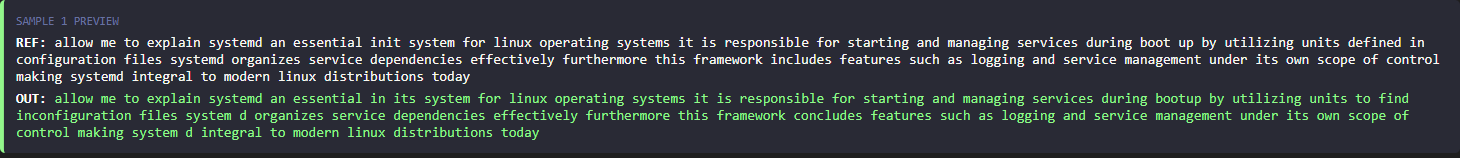
The model demonstrates high-fidelity recognition of specialized technical entities, specifically those where the written form deviates from standard English phonetic patterns.

1.  **Successful Graphemic Mapping:** * The model successfully learned to map the vocalized pronunciation *"System-D"* to the correct technical string **`systemd`**. 
    * It correctly identifies industry-specific terms like **`linux`**, **`bootup`**, and **`dependencies`** that often confuse general-purpose models.
    
2.  **Acoustic vs. Contextual Challenges:**
    * **Acoustic Success:** The model's "ear" is now highly tuned to technical phonemes.
    * **Contextual Limitation:** Minor "Acoustic Homophones" still occur—most notably transcribing the technical term **`init`** as the phonetically identical phrase **`in its`**. 
    * *Conclusion:* The **Acoustic Model** is now optimized. These remaining errors are expected at this stage and would be resolved by integrating a **Language Model (LM)** to provide contextual/grammatical correction (e.g., favoring "init" in a Linux context).